<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Undersaturated Volumetric Reservoir


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Virginia Hills Beaverhill Lake Field (Tarek Ahmed, Example 11-3)
# Undersaturated Volumetric Reservoir — All pressures above Pb

Pi, Pb, Boi = 3685, 1500, 1.3102
Swi, cw, cf, Bw = 0.24, 3.62e-6, 4.95e-6, 1.0
N_vol = 270.6  # Volumetric estimate (MMSTB)

data = pd.DataFrame({
    'P':  [3685,3680,3676,3667,3664,3640,3605,3567,3515,3448,3360,3275,3188],
    'Bo': [1.3102,1.3104,1.3104,1.3105,1.3105,1.3109,1.3116,1.3122,1.3128,1.3130,1.3150,1.3160,1.3170],
    'Np': [0,20.481,34.750,78.557,101.846,215.681,364.613,542.985,841.591,1273.530,1691.887,2127.077,2575.330],
    'Wp': [0,0,0,0,0,0,0,0.159,0.805,2.579,5.008,6.500,8.000]
})

data

,P,Bo,Np,Wp
0,3685,1.3102,0.000,0.000
1,3680,1.3104,20.481,0.000
2,3676,1.3104,34.750,0.000
3,3667,1.3105,78.557,0.000
4,3664,1.3105,101.846,0.000
5,3640,1.3109,215.681,0.000
6,3605,1.3116,364.613,0.000
7,3567,1.3122,542.985,0.159
8,3515,1.3128,841.591,0.805
9,3448,1.3130,1273.530,2.579


***MBE Terms***

In [ ]:
dP  = Pi - data['P']
F   = data['Np'] * data['Bo'] + data['Wp'] * Bw
Eo  = data['Bo'] - Boi
Efw = Boi * (cw * Swi + cf) / (1 - Swi) * dP
Et  = Eo + Efw

pd.DataFrame({
    'P': data['P'], 'Np': data['Np'], 'F': F.round(3),
    'Eo': Eo.round(6), 'Efw': Efw.round(6), 'Eo+Efw': Et.round(6)
})

,P,Np,F,Eo,Efw,Eo+Efw
0,3685,0.000,0.000,0.0000,0.000000,0.000000
1,3680,20.481,26.838,0.0002,0.000050,0.000250
2,3676,34.750,45.536,0.0002,0.000090,0.000290
3,3667,78.557,102.949,0.0003,0.000181,0.000481
4,3664,101.846,133.469,0.0003,0.000211,0.000511
5,3640,215.681,282.736,0.0007,0.000451,0.001151
6,3605,364.613,478.226,0.0014,0.000803,0.002203
7,3567,542.985,712.664,0.0020,0.001184,0.003184
8,3515,841.591,1105.646,0.0026,0.001705,0.004305
9,3448,1273.530,1674.724,0.0028,0.002377,0.005177


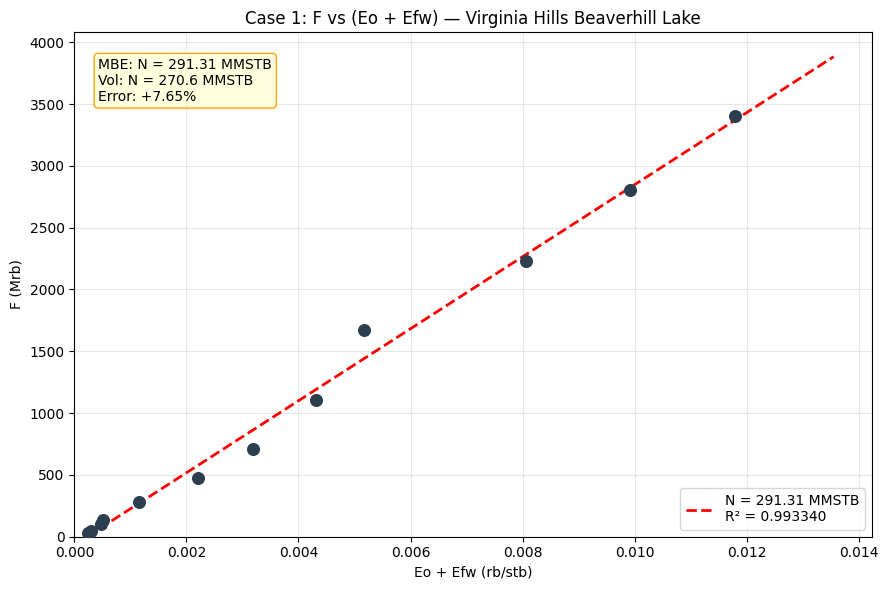

N (MBE) = 291.31 MMSTB | N (Vol) = 270.6 MMSTB | Error = +7.65% | R² = 0.993340


In [ ]:
mask = data['Np'] > 0
x, y = Et[mask].values, F[mask].values

slope, intercept, r, _, _ = linregress(x, y)
N_mbe = slope / 1000  # MMSTB
err = (N_mbe - N_vol) / N_vol * 100

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, c='#2c3e50', s=70, zorder=5)
xl = np.linspace(0, x.max() * 1.15, 100)
ax.plot(xl, slope * xl + intercept, 'r--', lw=2, label=f'N = {N_mbe:.2f} MMSTB\nR² = {r**2:.6f}')

ax.text(0.03, 0.95, f'MBE: N = {N_mbe:.2f} MMSTB\nVol: N = {N_vol} MMSTB\nError: {err:+.2f}%',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='orange'))

ax.set_xlabel('Eo + Efw (rb/stb)')
ax.set_ylabel('F (Mrb)')
ax.set_title('Case 1: F vs (Eo + Efw) — Virginia Hills Beaverhill Lake')
ax.legend(loc='lower right')
ax.set_xlim(0); ax.set_ylim(0); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N (MBE) = {N_mbe:.2f} MMSTB | N (Vol) = {N_vol} MMSTB | Error = {err:+.2f}% | R² = {r**2:.6f}")

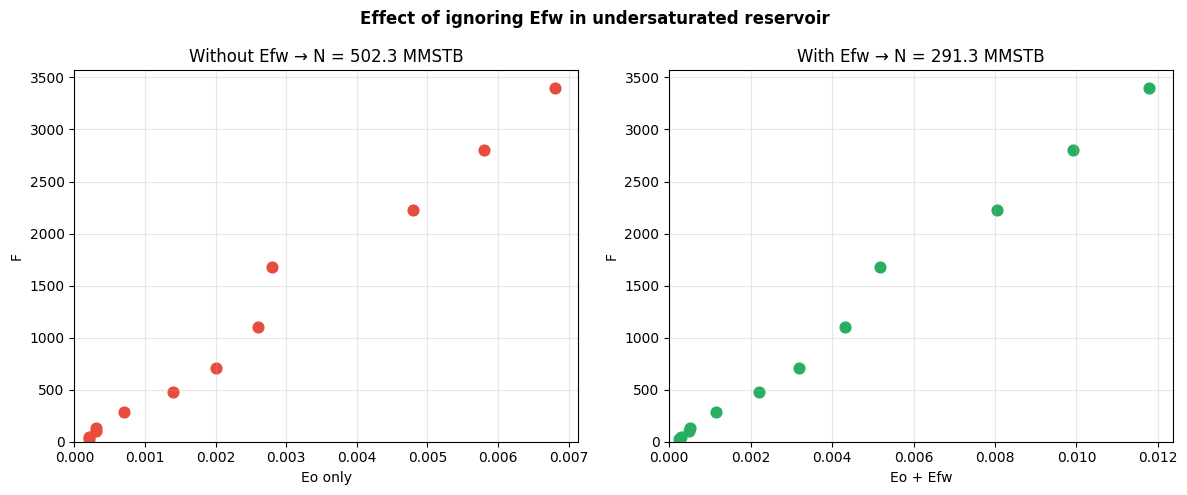

Without Efw: N = 502.3 MMSTB | With Efw: N = 291.3 MMSTB | Volumetric: 270.6 MMSTB


In [ ]:
slope2, _, r2, _, _ = linregress(Eo[mask].values, y)
N_no_efw = slope2 / 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(Eo[mask], y, c='#e74c3c', s=60); ax1.set_title(f'Without Efw → N = {N_no_efw:.1f} MMSTB')
ax1.set_xlabel('Eo only'); ax1.set_ylabel('F'); ax1.set_xlim(0); ax1.set_ylim(0); ax1.grid(alpha=0.3)

ax2.scatter(x, y, c='#27ae60', s=60); ax2.set_title(f'With Efw → N = {N_mbe:.1f} MMSTB')
ax2.set_xlabel('Eo + Efw'); ax2.set_ylabel('F'); ax2.set_xlim(0); ax2.set_ylim(0); ax2.grid(alpha=0.3)

plt.suptitle('Effect of ignoring Efw in undersaturated reservoir', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Without Efw: N = {N_no_efw:.1f} MMSTB | With Efw: N = {N_mbe:.1f} MMSTB | Volumetric: {N_vol} MMSTB")

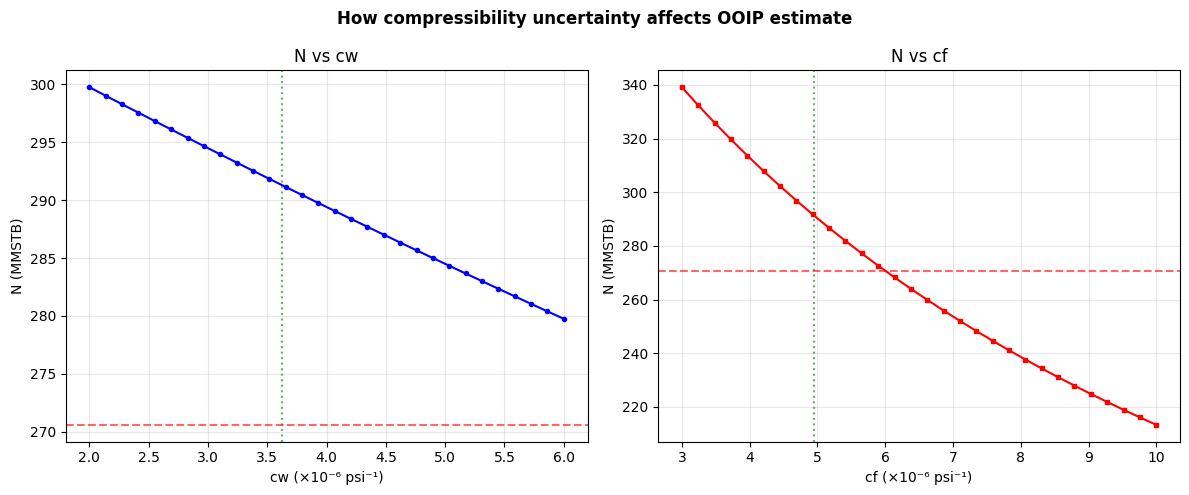

In [ ]:
def get_N(cw_val, cf_val):
    efw = Boi * (cw_val * Swi + cf_val) / (1 - Swi) * dP[mask].values
    return linregress(Eo[mask].values + efw, y).slope / 1000

cw_r = np.linspace(2e-6, 6e-6, 30)
cf_r = np.linspace(3e-6, 10e-6, 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(cw_r*1e6, [get_N(c, cf) for c in cw_r], 'b-o', ms=3)
ax1.axhline(N_vol, color='r', ls='--', alpha=0.6); ax1.axvline(cw*1e6, color='g', ls=':', alpha=0.6)
ax1.set_xlabel('cw (×10⁻⁶ psi⁻¹)'); ax1.set_ylabel('N (MMSTB)'); ax1.set_title('N vs cw'); ax1.grid(alpha=0.3)

ax2.plot(cf_r*1e6, [get_N(cw, c) for c in cf_r], 'r-s', ms=3)
ax2.axhline(N_vol, color='r', ls='--', alpha=0.6); ax2.axvline(cf*1e6, color='g', ls=':', alpha=0.6)
ax2.set_xlabel('cf (×10⁻⁶ psi⁻¹)'); ax2.set_ylabel('N (MMSTB)'); ax2.set_title('N vs cf'); ax2.grid(alpha=0.3)

plt.suptitle('How compressibility uncertainty affects OOIP estimate', fontweight='bold')
plt.tight_layout()
plt.show()

**Summary**

In [ ]:
print("=" * 50)
print("  CASE 1 SUMMARY")
print("  Virginia Hills Beaverhill Lake Field")
print("  Undersaturated Volumetric Reservoir")
print("=" * 50)
print(f"  MBE (with Efw):    N = {N_mbe:.2f} MMSTB")
print(f"  MBE (without Efw): N = {N_no_efw:.1f} MMSTB")
print(f"  Volumetric:        N = {N_vol} MMSTB")
print(f"  Error (with Efw):  {err:+.2f}%")
print(f"  R²:                {r**2:.6f}")
print()
print("  Takeaway:")
print("  - Efw matters in undersaturated reservoirs")
print(f"  - Ignoring it overestimates N by {((N_no_efw-N_vol)/N_vol)*100:.0f}%")
print(f"  - cf has more impact on N than cw")

  CASE 1 SUMMARY
  Virginia Hills Beaverhill Lake Field
  Undersaturated Volumetric Reservoir
  MBE (with Efw):    N = 291.31 MMSTB
  MBE (without Efw): N = 502.3 MMSTB
  Volumetric:        N = 270.6 MMSTB
  Error (with Efw):  +7.65%
  R²:                0.993340

  Takeaway:
  - Efw matters in undersaturated reservoirs
  - Ignoring it overestimates N by 86%
  - cf has more impact on N than cw
